In [ ]:
from flower_model._kmeans import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [66]:
N = 127
sigma = 150.
k = 50
steps = 12
SPH_KMEANS_ITERS = 50
device='cuda'

low_freq_upper= 3.7
high_freq_lower = 10.6

eye_pos = [63.5, 63.5]
k_around_eye = 8

In [46]:
filters, r = _gabor_like_filters(N, sigma, 20, 0.8)
print(filters.shape)
print(r.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


(1281, 127, 127)
(1281,)


In [47]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

r = torch.tensor(r, device=device)

In [48]:
filters, filter_pos = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

r = r.repeat((steps*2)**2)

print(filters.shape)
print(filter_pos.shape)
print(r.shape)

torch.Size([737856, 150, 150])
torch.Size([737856, 2])
torch.Size([737856])


In [49]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [50]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [51]:
centroid_list = []
centroid_r_list = []
centroid_pos_list = []

for cluster in range(k):
    cluster_mask = labels == cluster
    filters_in_cluster = filters[cluster_mask]
    r_in_cluster = r[cluster_mask]
    pos_in_cluster = filter_pos[cluster_mask]

    centroid_list.append(torch.mean(filters_in_cluster, dim=0))
    centroid_r_list.append(torch.mean(r_in_cluster))
    centroid_pos_list.append(torch.mean(pos_in_cluster, dim=0))

centroids = torch.stack(centroid_list)
centroids_r = torch.hstack(centroid_r_list)
centroids_pos = torch.stack(centroid_pos_list)

print(centroids.shape)
print(centroids_r.shape)
print(centroids_pos.shape)

centroids = centroids.view(-1, shift_dim*shift_dim)

torch.Size([50, 22500])
torch.Size([50])
torch.Size([50, 2])


tensor([53.9088, 65.4383], device='cuda:0')


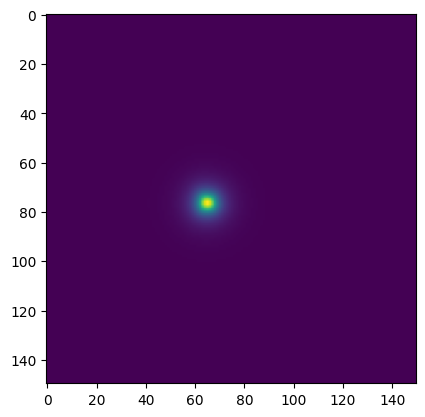

In [52]:
print(centroids_pos[0])
plt.imshow(centroids[0].view(shift_dim, shift_dim).cpu())
plt.show()

In [53]:
low_freq_upper= 16.
high_freq_lower = 30.

low_freq_mask = centroids_r < low_freq_upper
mid_freq_mask = (centroids_r > low_freq_upper) & (centroids_r < high_freq_lower)
high_freq_mask = centroids_r > high_freq_lower

low_freq_centroids = centroids[low_freq_mask]
high_freq_centroids = centroids[high_freq_mask]
mid_freq_centroids = centroids[mid_freq_mask]

print(low_freq_centroids.shape)
print(mid_freq_centroids.shape)
print(high_freq_centroids.shape)

torch.Size([8, 22500])
torch.Size([11, 22500])
torch.Size([31, 22500])


In [67]:
eye_pos = torch.tensor(eye_pos, device=device)
pos_diff = centroids_pos - eye_pos
centoroid_distance = torch.linalg.vector_norm(pos_diff, dim=1)

low_freq_distance = centoroid_distance[low_freq_mask]
mid_freq_distance = centoroid_distance[mid_freq_mask]
high_freq_distance = centoroid_distance[high_freq_mask]

low_freq_centroids_eye = low_freq_centroids[low_freq_distance.topk(k_around_eye, largest=False).indices]
mid_freq_centroids_eye = mid_freq_centroids[mid_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_centroids_eye = high_freq_centroids[high_freq_distance.topk(k_around_eye, largest=False).indices]

print(low_freq_centroids_eye.shape)
print(mid_freq_centroids_eye.shape)
print(high_freq_centroids_eye.shape)

torch.Size([8, 22500])
torch.Size([8, 22500])
torch.Size([8, 22500])


In [69]:
print(low_freq_distance.topk(k_around_eye, largest=False).values)
print(mid_freq_distance.topk(k_around_eye, largest=False).values)
print(high_freq_distance.topk(k_around_eye, largest=False).values)

tensor([ 5.6331,  7.0830,  7.1101,  7.4429, 10.8747, 11.2919, 11.5933, 11.7865],
       device='cuda:0')
tensor([ 2.3010,  4.2085,  7.9043,  8.8177,  8.9169,  9.0129,  9.1826, 11.2027],
       device='cuda:0')
tensor([1.2791, 3.7754, 3.8645, 4.2128, 4.6485, 5.5995, 6.5070, 7.0919],
       device='cuda:0')


torch.Size([8, 22500])


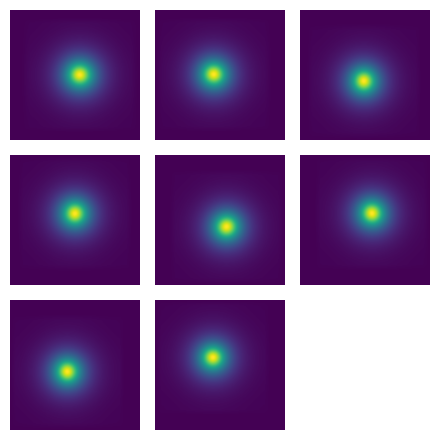

torch.Size([8, 22500])


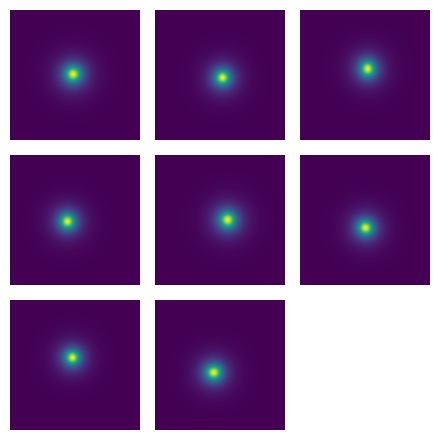

torch.Size([8, 22500])


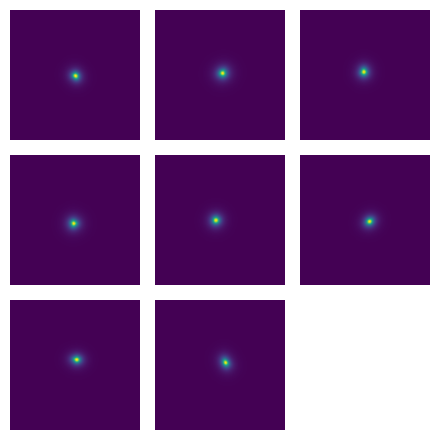

In [68]:
for c in [low_freq_centroids_eye, mid_freq_centroids_eye, high_freq_centroids_eye]:
    f = c.squeeze(0).cpu()
    print(f.shape)
    n = f.shape[0]
    size = int(math.sqrt(f.shape[1]))
    assert size * size == f.shape[1], "expected square (H*W)"

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = np.atleast_1d(axes).flatten()

    for i in range(rows * cols):
        ax = axes[i]
        if i < n:
            img = f[i].reshape(size, size).numpy()
            ax.imshow(img, cmap="viridis")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

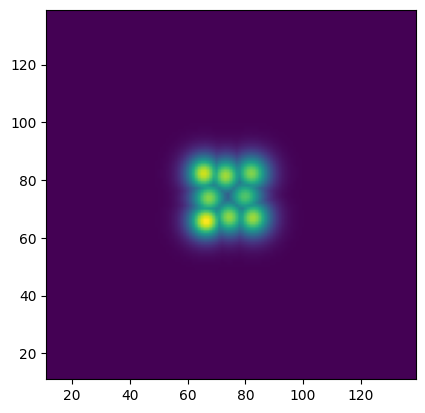

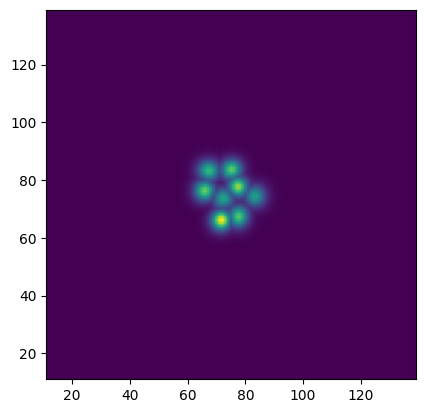

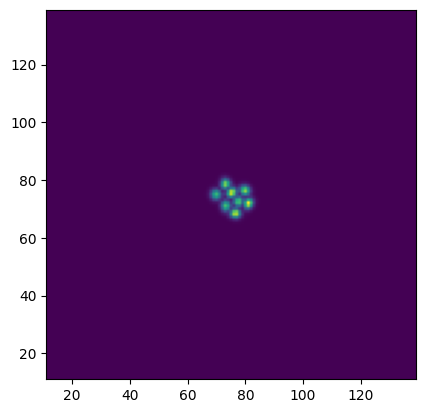

In [70]:
scale = 5.5
for c in [low_freq_centroids_eye**scale, mid_freq_centroids_eye**scale, high_freq_centroids_eye**scale]:
    f = c.amax(dim=0)
    f = f.view(shift_dim, shift_dim)
    plt.imshow(f.cpu())
    plt.xlim(shift_dim//2 - (N+1)//2, shift_dim//2 - (N+1)//2 + N+1)
    plt.ylim(shift_dim//2 - (N+1)//2, shift_dim//2 - (N+1)//2 + N+1)
    plt.show()

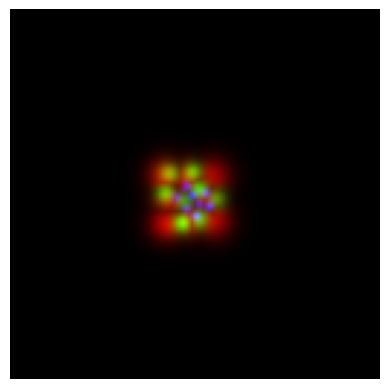

In [71]:
img1 = low_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale
img2 = mid_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale
img3 = high_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale

max = torch.stack([img1, img2, img3]).max()
min = torch.stack([img1, img2, img3]).min()

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

img1 = normalize(img1)
img2 = normalize(img2)
img3 = normalize(img3)

rgb = torch.stack([img1, img2, img3], dim=-1)

rgb_np = rgb.cpu().numpy()

plt.imshow(rgb_np)
plt.axis("off")
plt.xlim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.ylim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.show()

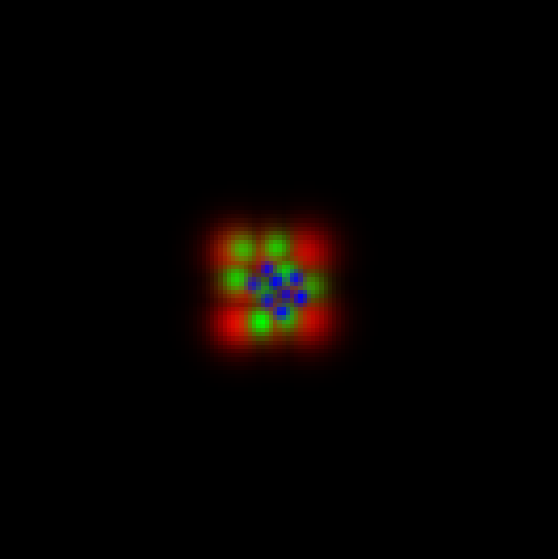

In [72]:
img_low  = (low_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5
img_mid  = (mid_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5
img_high = (high_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5

max = torch.stack([img_low, img_mid, img_high]).max()
min = torch.stack([img_low, img_mid, img_high]).min()

low  = normalize(img_low).cpu().numpy()
mid  = normalize(img_mid).cpu().numpy()
high = normalize(img_high).cpu().numpy()

H, W = low.shape

layer_low = torch.zeros(H, W, 4)
layer_mid = torch.zeros(H, W, 4)
layer_high = torch.zeros(H, W, 4)

layer_low[..., 0] = 1.0
layer_low[..., 3] = torch.tensor(low)

layer_mid[..., 1] = 1.0
layer_mid[..., 3] = torch.tensor(mid)

layer_high[..., 2] = 1.0 
layer_high[..., 3] = torch.tensor(high)

layer_low  = layer_low.numpy()
layer_mid  = layer_mid.numpy()
layer_high = layer_high.numpy()

fig, ax = plt.subplots(figsize=(7, 7), facecolor="black")
ax.set_facecolor("black")

ax.imshow(layer_low)
ax.imshow(layer_mid)
ax.imshow(layer_high)

ax.axis("off")
ax.set_xlim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
ax.set_ylim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.show()

In [73]:
low_freq_pos = centroids_pos[low_freq_mask]
mid_freq_pos = centroids_pos[mid_freq_mask]
high_freq_pos = centroids_pos[high_freq_mask]

low_freq_pos_eye = low_freq_pos[low_freq_distance.topk(k_around_eye, largest=False).indices]
mid_freq_pos_eye = mid_freq_pos[mid_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_pos_eye = high_freq_pos[high_freq_distance.topk(k_around_eye, largest=False).indices]

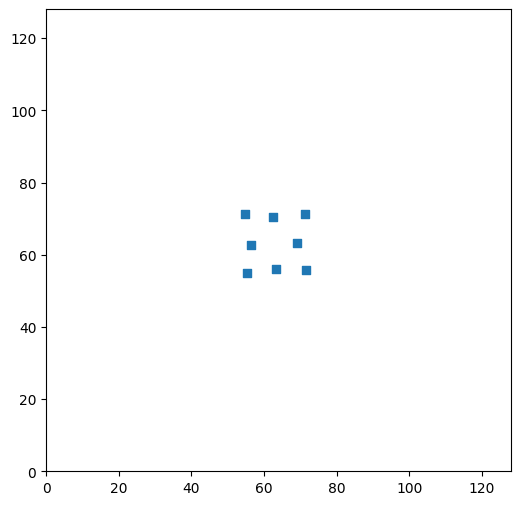

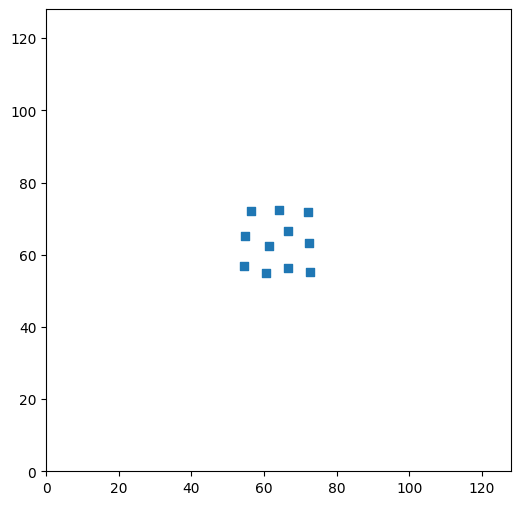

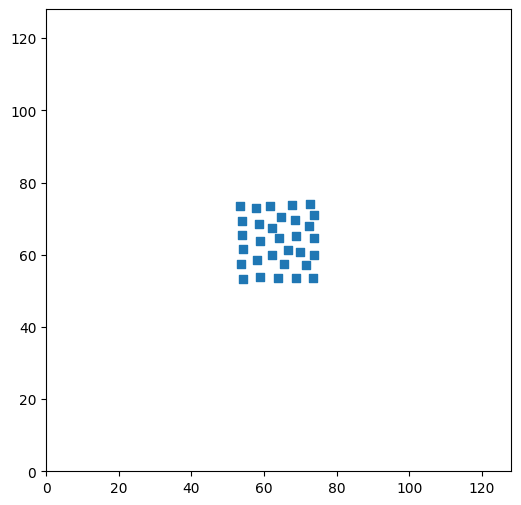

In [74]:
low = low_freq_pos.cpu().numpy()
mid = mid_freq_pos.cpu().numpy()
high = high_freq_pos.cpu().numpy()

for f in [low, mid, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N+1)
    ax.set_ylim(0, N+1)
    plt.show()

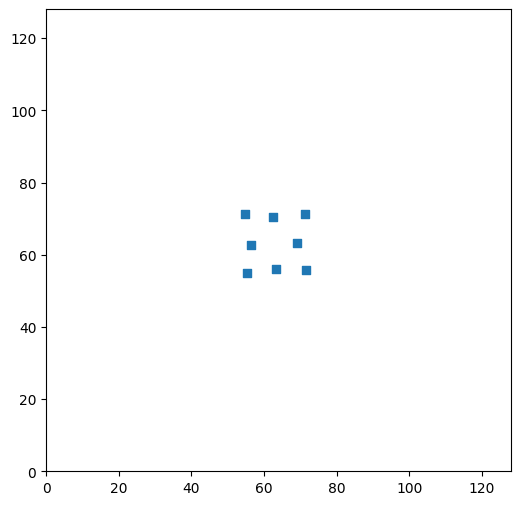

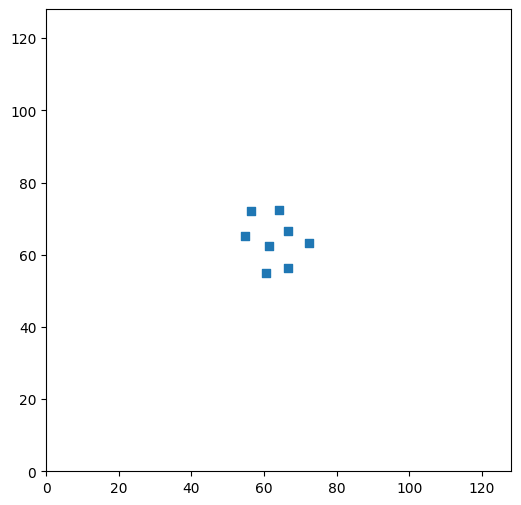

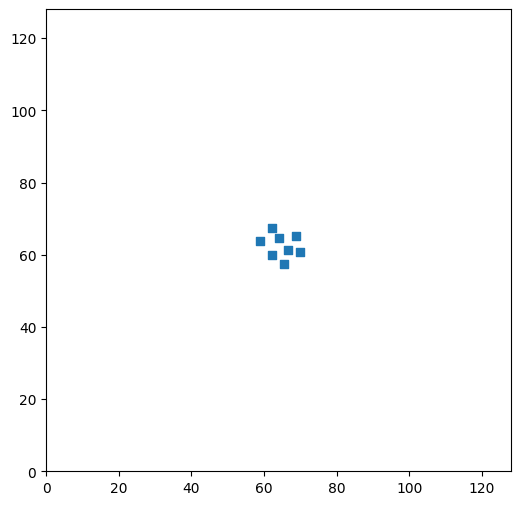

In [75]:
low = low_freq_pos_eye.cpu().numpy()
mid = mid_freq_pos_eye.cpu().numpy()
high = high_freq_pos_eye.cpu().numpy()

for f in [low, mid, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N+1)
    ax.set_ylim(0, N+1)
    plt.show()

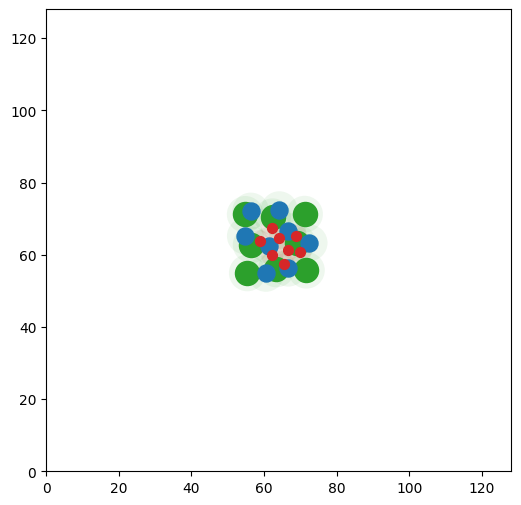

In [76]:
fig, ax = plt.subplots(figsize=(6, 6))

# ax.scatter(low[:, 0],  low[:, 1],  c="tab:green",  marker="s", s=300, label="low")
# ax.scatter(mid[:, 0],  mid[:, 1],  c="tab:blue", marker="s", s=150, label="mid")
# ax.scatter(high[:, 0], high[:, 1], c="tab:red",   marker="s", s=50, label="high")

ax.scatter(low[:,0], low[:,1], s=700, c="tab:green", marker="o", alpha=0.08, edgecolors="none")
ax.scatter(mid[:,0], mid[:,1], s=700, c="tab:green", marker="o", alpha=0.08, edgecolors="none")
ax.scatter(high[:,0], high[:,1], s=250, c="tab:red", marker="o", alpha=0.08, edgecolors="none")

ax.scatter(low[:,0], low[:,1], s=300, c="tab:green", marker="o")
ax.scatter(mid[:, 0],  mid[:, 1],  c="tab:blue", marker="o", s=150, label="mid")
ax.scatter(high[:,0], high[:,1], s=50, c="tab:red", marker="o")

ax.set_xlim(0, N+1)
ax.set_ylim(0, N+1)
plt.show()